In [468]:
import pandas as pd

In [469]:
data = pd.read_csv("online_shoppers_intention.csv")

In [470]:
print(data.head())

   Administrative  Administrative_Duration  Informational  \
0               0                 0.000000              0   
1               4                52.000000              1   
2               4               106.500000              0   
3               9               497.166667              0   
4               0                 0.000000              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               6              1156.500000   
1                     7.0              46              3087.000000   
2                     0.0              12               806.250000   
3                     0.0              20              1170.166667   
4                     0.0               3                17.000000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0     0.000000   0.033333    0.000000         0.0   Nov                 2   
1     0.003774   0.021384   16.946438         0.0   Mar   

In [471]:
data.dropna()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.000000,0,0.00,6,1156.500000,0.000000,0.033333,0.000000,0.0,Nov,2,2,1,20,Returning_Visitor,False,False
1,4,52.000000,1,7.00,46,3087.000000,0.003774,0.021384,16.946438,0.0,Mar,2,2,3,8,Returning_Visitor,False,True
2,4,106.500000,0,0.00,12,806.250000,0.012500,0.029167,0.000000,0.0,Dec,2,2,1,2,Returning_Visitor,False,False
3,9,497.166667,0,0.00,20,1170.166667,0.012121,0.023485,0.000000,0.0,Nov,3,2,3,2,Returning_Visitor,False,False
4,0,0.000000,0,0.00,3,17.000000,0.000000,0.033333,0.000000,0.0,Mar,1,1,1,3,Returning_Visitor,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,4,46.300000,0,0.00,2,22.833333,0.000000,0.033333,0.000000,0.0,Nov,2,2,6,2,New_Visitor,True,True
12326,0,0.000000,0,0.00,19,989.333333,0.000000,0.011111,25.109000,0.0,May,3,2,1,2,New_Visitor,True,True
12327,4,68.107692,6,1022.25,104,8130.964914,0.003788,0.017635,5.907476,0.0,Nov,1,1,4,2,Returning_Visitor,False,True
12328,0,0.000000,0,0.00,39,963.166667,0.005405,0.028829,9.922973,0.6,May,2,6,2,3,Returning_Visitor,False,False


In [472]:
data.drop_duplicates()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.000000,0,0.00,6,1156.500000,0.000000,0.033333,0.000000,0.0,Nov,2,2,1,20,Returning_Visitor,False,False
1,4,52.000000,1,7.00,46,3087.000000,0.003774,0.021384,16.946438,0.0,Mar,2,2,3,8,Returning_Visitor,False,True
2,4,106.500000,0,0.00,12,806.250000,0.012500,0.029167,0.000000,0.0,Dec,2,2,1,2,Returning_Visitor,False,False
3,9,497.166667,0,0.00,20,1170.166667,0.012121,0.023485,0.000000,0.0,Nov,3,2,3,2,Returning_Visitor,False,False
4,0,0.000000,0,0.00,3,17.000000,0.000000,0.033333,0.000000,0.0,Mar,1,1,1,3,Returning_Visitor,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,4,46.300000,0,0.00,2,22.833333,0.000000,0.033333,0.000000,0.0,Nov,2,2,6,2,New_Visitor,True,True
12326,0,0.000000,0,0.00,19,989.333333,0.000000,0.011111,25.109000,0.0,May,3,2,1,2,New_Visitor,True,True
12327,4,68.107692,6,1022.25,104,8130.964914,0.003788,0.017635,5.907476,0.0,Nov,1,1,4,2,Returning_Visitor,False,True
12328,0,0.000000,0,0.00,39,963.166667,0.005405,0.028829,9.922973,0.6,May,2,6,2,3,Returning_Visitor,False,False


In [473]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

How do Bounce Rate, Exit Rate, and Page Value differ between sessions that result in a purchase and those that don’t? [Variables: BounceRates, ExitRates, PageValues, Revenue]

In [474]:
selected_vars = ['BounceRates', 'ExitRates', 'PageValues', 'Revenue']
data1 = data[selected_vars]

In [475]:
purchases = data1[data1['Revenue'] == True]
non_purchases = data1[data1['Revenue'] == False]

In [476]:
print("Descriptive Statistics for Purchases:")
print(purchases.describe()[['BounceRates', 'ExitRates', 'PageValues']])
print("\nDescriptive Statistics for Non-Purchases:")
print(non_purchases.describe()[['BounceRates', 'ExitRates', 'PageValues']])
print("\nT-Test Results (Purchases vs Non-Purchases):")
for col in ['BounceRates', 'ExitRates', 'PageValues']:
    t_stat, p_value = ttest_ind(purchases[col], non_purchases[col], equal_var=False)
    print(f"{col}: t-stat = {t_stat:.4f}, p-value = {p_value:.4e}")
sns.set(style="whitegrid")
data1_melted = data1.melt(id_vars='Revenue', 
                    value_vars=['BounceRates', 'ExitRates', 'PageValues'],
                    var_name='Metric', value_name='Value')

Descriptive Statistics for Purchases:
       BounceRates    ExitRates   PageValues
count  1908.000000  1908.000000  1908.000000
mean      0.005117     0.019555    27.264518
std       0.012185     0.016463    35.191954
min       0.000000     0.000000     0.000000
25%       0.000000     0.009521     3.641144
50%       0.000000     0.016000    16.758134
75%       0.006452     0.025000    38.897742
max       0.200000     0.200000   361.763742

Descriptive Statistics for Non-Purchases:
        BounceRates     ExitRates    PageValues
count  10422.000000  10422.000000  10422.000000
mean       0.025317      0.047378      1.975998
std        0.051877      0.051231      9.072424
min        0.000000      0.000000      0.000000
25%        0.000000      0.015560      0.000000
50%        0.004255      0.028571      0.000000
75%        0.020000      0.053846      0.000000
max        0.200000      0.200000    246.758590

T-Test Results (Purchases vs Non-Purchases):
BounceRates: t-stat = -34.8464, p-va

chatgpt explaination :
Descriptive Statistics
Metric	Purchase (Mean ± Std)	Non-Purchase (Mean ± Std)	Interpretation
Bounce Rate	0.0051 ± 0.0122	0.0253 ± 0.0519	Users who made a purchase were much less likely to bounce.
Exit Rate	0.0196 ± 0.0165	0.0474 ± 0.0512	Purchasers had lower likelihood of leaving pages — more engagement.
Page Value	27.26 ± 35.19	1.98 ± 9.07	Pages in purchase sessions were much more valuable, likely due to contributing to conversion.

Additional Observations:
Median Page Value (50%) for non-purchase = 0.0: This implies that in most non-purchase sessions, no page had a measurable monetary impact.

Purchases have higher spread (std) in Page Values: Reflects a wide range of value across different pages visited during purchasing sessions.


T-Test Results (Statistical Significance)
Metric	t-statistic	p-value	Interpretation
Bounce Rate	-34.85	2.59e-253 (≈ 0)	Extremely significant difference; bounce rates are much lower when purchases happen.
Exit Rate	-44.33	≈ 0	Extremely significant; exit behavior differs greatly between purchasers and non-purchasers.
Page Value	31.20	9.61e-174	Strong positive difference in Page Value for purchase sessions.

p-value < 0.05 indicates statistically significant differences.
Here, p-values are effectively zero, meaning the differences are highly significant and not due to chance.

Conclusion
Visitors who didn't purchase tend to bounce more, exit more, and view pages that contribute less to conversions.

The metrics strongly differentiate purchasing vs. non-purchasing behavior, and this can inform optimization strategies like:

Reducing bounce/exit on key pages

Increasing content or call-to-action value to boost PageValue

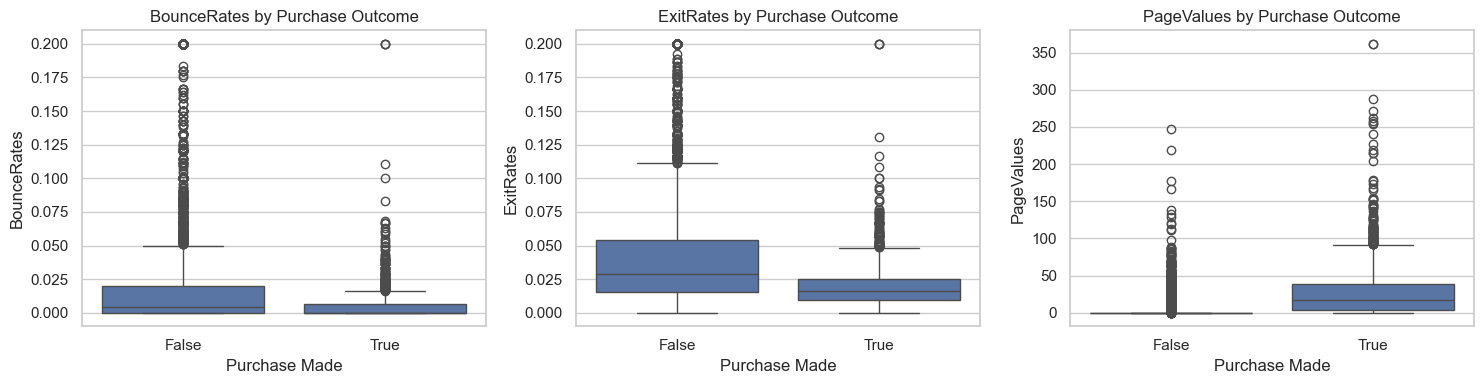

In [477]:
metrics = ['BounceRates', 'ExitRates', 'PageValues']
plt.figure(figsize=(15, 4))

for i, metric in enumerate(metrics):
    plt.subplot(1, 3, i+1)
    sns.boxplot(data=data1, x='Revenue', y=metric)
    plt.title(f'{metric} by Purchase Outcome')
    plt.xlabel('Purchase Made')
    plt.ylabel(metric)

plt.tight_layout()
plt.show()

chatgpt explaination :
 Panel 1: BounceRates by Purchase Outcome
Median Bounce Rate is much lower for purchase sessions (True) compared to non-purchase sessions.

There are many more high bounce outliers in non-purchase sessions.

Interpretation: Purchasers are less likely to leave the site immediately after viewing only one page.



Panel 2: ExitRates by Purchase Outcome
Again, exit rates are lower in sessions that resulted in a purchase.

The distribution for non-purchases is wider and more skewed, with a higher median and more frequent high exit rates.

Interpretation: Purchasers tend to navigate more pages and don’t exit prematurely — they follow through the funnel more effectively.



Panel 3: PageValues by Purchase Outcome
Massive difference in distribution:

Non-purchase sessions have mostly zero Page Value (box is flat at 0).

Purchase sessions show much higher Page Values, with a wider spread and higher median.

Interpretation: Pages visited in sessions that lead to purchases contribute significantly more to potential revenue (e.g., product, cart, checkout pages).



Summary of Insights
Metric	Purchasers (True)	Non-Purchasers (False)	Key Insight
Bounce Rate	Lower, tightly clustered near 0	Higher, wide range of values	Purchasers engage early
Exit Rate	Lower, more consistent	Higher, with more early exits	Purchasers navigate deeper
Page Value	High and variable	Mostly 0	Pages seen by purchasers contribute to revenue

What patterns emerge in Visitor Type, Traffic Type, and Browser usage when comparing sessions with purchases versus sessions without purchases? [Variables: VisitorType, TrafficType, Browser, Revenue]

In [478]:
print(data.columns.tolist())

['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']


In [479]:
data.columns = data.columns.str.strip()
data['Revenue'] = data['Revenue'].astype(str).str.strip().str.upper().map({'TRUE': True, 'FALSE': False, 'TRUE.': True, 'FALSE.': False})

In [480]:
print("✅ Revenue unique values:", data['Revenue'].unique())

✅ Revenue unique values: [False  True]



 Analysis for: VisitorType
Revenue            False  True  % Purchase
VisitorType                               
New_Visitor         1272   422       24.91
Other                 69    16       18.82
Returning_Visitor   9081  1470       13.93


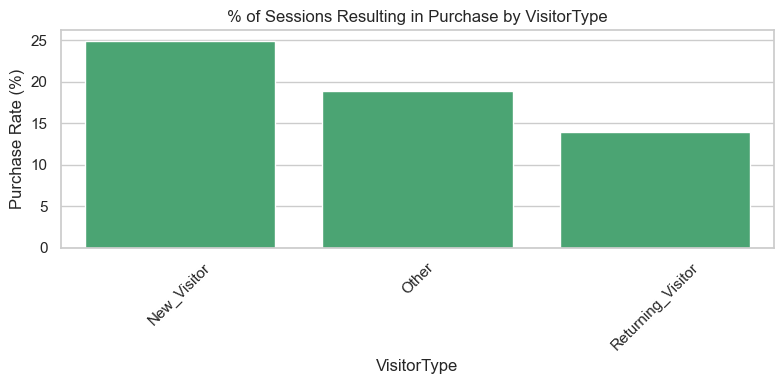


 Analysis for: TrafficType
Revenue      False  True  % Purchase
TrafficType                         
1             2189   262       10.69
2             3066   847       21.65
3             1872   180        8.77
4              904   165       15.43
5              204    56       21.54
6              391    53       11.94
7               28    12       30.00
8              248    95       27.70
9               38     4        9.52
10             360    90       20.00
11             200    47       19.03
12               1     0        0.00
13             695    43        5.83
14              11     2       15.38
15              38     0        0.00
16               2     1       33.33
17               1     0        0.00
18              10     0        0.00
19              16     1        5.88
20             148    50       25.25


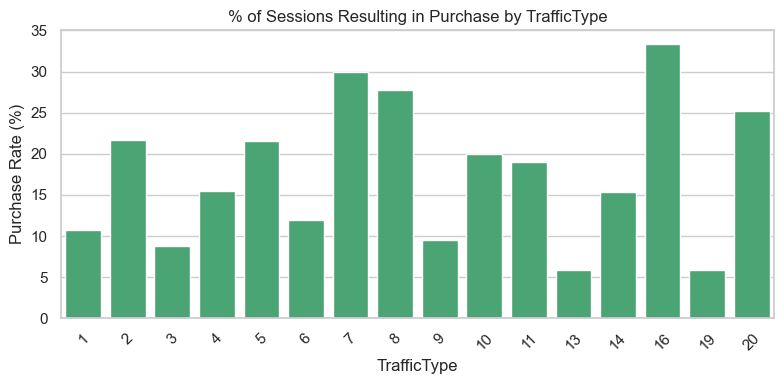


 Analysis for: Browser
Revenue  False  True  % Purchase
Browser                         
1         2097   365       14.83
2         6738  1223       15.36
3          100     5        4.76
4          606   130       17.66
5          381    86       18.42
6          154    20       11.49
7           43     6       12.24
8          114    21       15.56
9            1     0        0.00
10         131    32       19.63
11           5     1       16.67
12           7     3       30.00
13          45    16       26.23


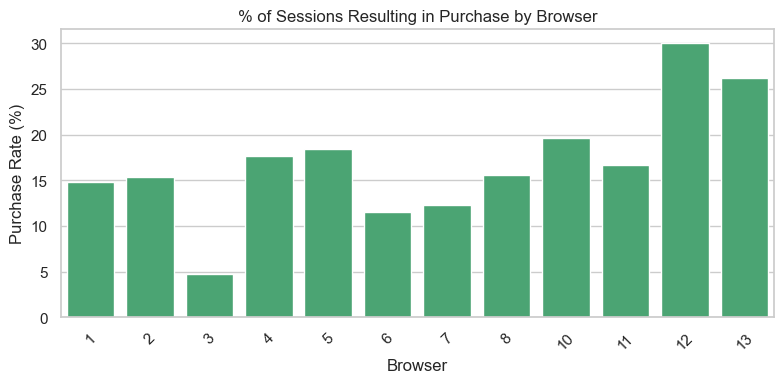

In [481]:
def analyze_category(data, column):
    print(f"\n Analysis for: {column}")
    
    # Frequency table by category and Revenue
    freq_table = data.groupby([column, 'Revenue']).size().unstack(fill_value=0)

    # Detect column presence
    present_cols = freq_table.columns.tolist()
    has_true = True in present_cols
    has_false = False in present_cols

    # Add totals and purchase %
    if has_true and has_false:
        freq_table['Total'] = freq_table[True] + freq_table[False]
        freq_table['% Purchase'] = round(freq_table[True] / freq_table['Total'] * 100, 2)
        print(freq_table[[False, True, '% Purchase']])
    elif has_true:
        freq_table['Total'] = freq_table[True]
        freq_table['% Purchase'] = 100.0
        print("⚠️ Only purchases found.")
        print(freq_table[[True, '% Purchase']])
    elif has_false:
        freq_table['Total'] = freq_table[False]
        freq_table['% Purchase'] = 0.0
        print("⚠️ No purchases found.")
        print(freq_table[[False, '% Purchase']])
    else:
        print("❌ No valid Revenue data.")
        return

    # Plot (if purchases exist)
    if has_true:
        perc_data = data.groupby([column, 'Revenue']).size().reset_index(name='Count')
        perc_data['Percent'] = perc_data.groupby(column)['Count'].transform(lambda x: x / x.sum() * 100)
        plot_data = perc_data[perc_data['Revenue'] == True]

        plt.figure(figsize=(8, 4))
        sns.barplot(data=plot_data, x=column, y='Percent', color='mediumseagreen')
        plt.title(f'% of Sessions Resulting in Purchase by {column}')
        plt.ylabel('Purchase Rate (%)')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# 🔁 Run on selected categorical variables
for col in ['VisitorType', 'TrafficType', 'Browser']:
    analyze_category(data, col)

chatgpt explaination :
 Visitor Type vs Purchase Behavior
Visitor Type	Purchase Rate (%)
New_Visitor	24.91%
Other	18.82%
Returning_Visitor	13.93%

📌 Interpretation:
New Visitors have the highest conversion rate (≈25%).

Returning Visitors are the largest group by count, but convert less (≈14%).

This suggests new users might come with stronger intent to buy, while returning visitors may just be browsing or comparing.


Traffic Type vs Purchase Behavior
Traffic Type	% Purchase	Notes
7	30.00	Very high, but very low sample (12 buyers)
16	33.33	Only 3 users total — unstable rate
8, 10, 2, 5	20–28%	Consistently high conversion
13, 15, 18, 17	~0–6%	Very low performance

📌 Interpretation:
Traffic Types 2, 5, 8, and 10 seem to generate most valuable leads — stable and sizeable.

Traffic types like 13, 15, 18 have very poor performance.

Some very high rates (e.g., Traffic Type 16) are likely due to small sample sizes → treat with caution.

Consider focusing marketing efforts on traffic sources 2, 5, 8, 10 — they convert well and have strong volume.

Browser vs Purchase Behavior
Browser	% Purchase	Notes
12	30.00%	Only 10 users → unstable
13	26.23	Promising
10, 5, 4	17–20%	Strong performers
3, 6, 7, 9	<12%	Weaker performers

📌 Interpretation:
Most users are on Browser 1 and 2 (high volume), with moderate conversion (~15%).

Browsers 10, 5, 4, 13 show higher conversion.

Browsers 3 and 9 are low-conversion and might be outdated/insecure.

Summary of Patterns
Feature	High-Converting Groups	Low-Converting Groups
VisitorType	New_Visitor (24.9%)	Returning_Visitor (13.9%)
TrafficType	2, 5, 8, 10	13, 15, 18
Browser	4, 5, 10, 13	3, 6, 9


Recommendations:
Focus Acquisition on High-Converting Traffic Types:

Run targeted campaigns through Traffic Types 2, 5, 8, 10.

Tailor UX for New Visitors:

Make first-time experience more streamlined since they convert better.

Audit Low-Performing Browsers:

Investigate issues on Browsers 3, 6, 9 (layout, loading times?).

Ignore Small Groups for Strategy:

Skip Traffic Type 16, Browser 12 — too small for reliable insights.



How does the number of pages viewed (ProductRelated) correlate with the Bounce Rate across all sessions? [Variables: ProductRelated, BounceRates]

In [482]:
data3= data[['ProductRelated', 'BounceRates']].dropna()

📊 Pearson Correlation between ProductRelated and BounceRates:
Correlation Coefficient (r): -0.2046
p-value: 1.2455e-116


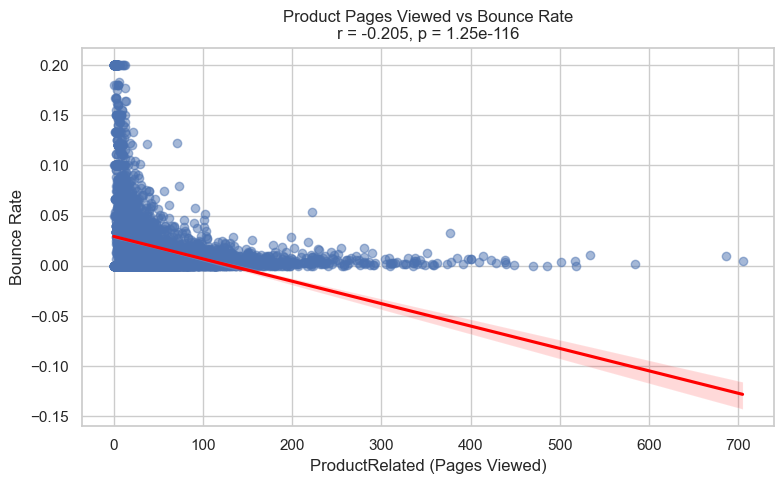

In [483]:
corr_coef, p_value = pearsonr(data3['ProductRelated'], data3['BounceRates'])

# Print correlation result
print(f"📊 Pearson Correlation between ProductRelated and BounceRates:")
print(f"Correlation Coefficient (r): {corr_coef:.4f}")
print(f"p-value: {p_value:.4e}")

# Plot with regression line
plt.figure(figsize=(8, 5))
sns.regplot(
    x='ProductRelated',
    y='BounceRates',
    data=data3,
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'}
)
plt.title(f'Product Pages Viewed vs Bounce Rate\nr = {corr_coef:.3f}, p = {p_value:.2e}')
plt.xlabel('ProductRelated (Pages Viewed)')
plt.ylabel('Bounce Rate')
plt.tight_layout()
plt.show()

chatgpt explaination :
Metric	Interpretation
r = -0.2046	A weak negative correlation
p ≈ 0	The result is statistically significant

Interpretation:
As users view more product-related pages, their bounce rate decreases.

The correlation is weak, but statistically significant due to the large dataset.

This makes intuitive sense — users who browse more products are more engaged and less likely to leave immediately.

Why It Matters:
A high bounce rate usually indicates low engagement.

Lower bounce rates among users who explore more products suggests:

They are more interested in shopping

They may be closer to a conversion (purchase)

Recommendation:
Encourage deeper product exploration:

Use "Related Products", "Customers Also Viewed", or "Recommended for You"

Consider tracking bounce rate by product category to refine UX or navigation.

Is there any relationship on the type of visitor with the traffic type to its exit rates which can lead to revenue? [Variables : ExitRates , TrafficType , VisitorType , Revenue]

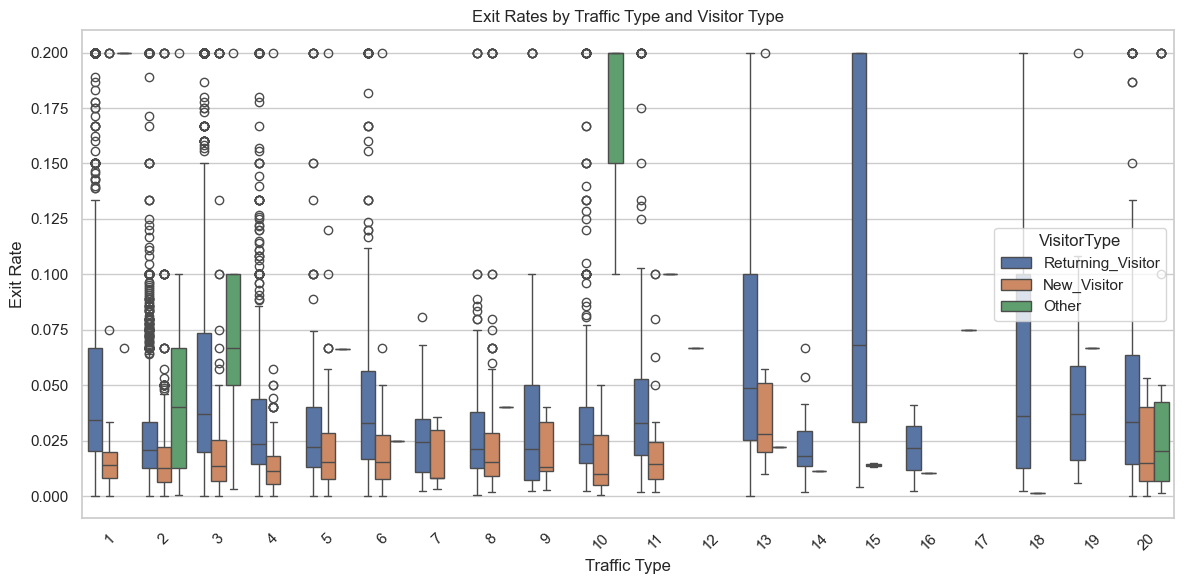

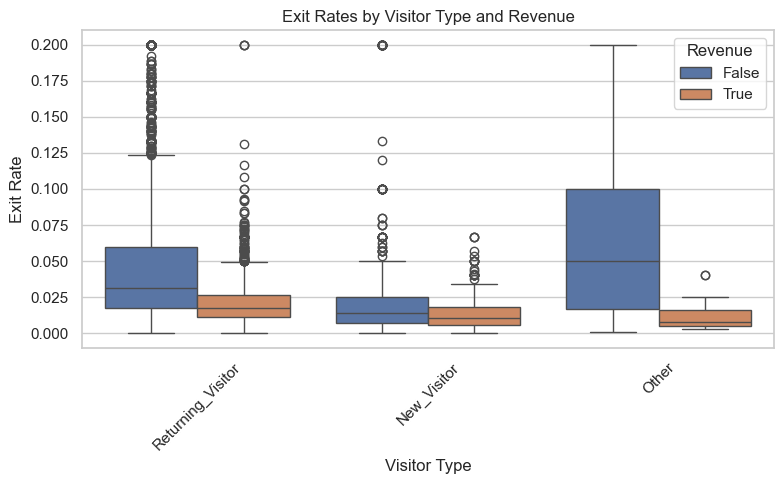

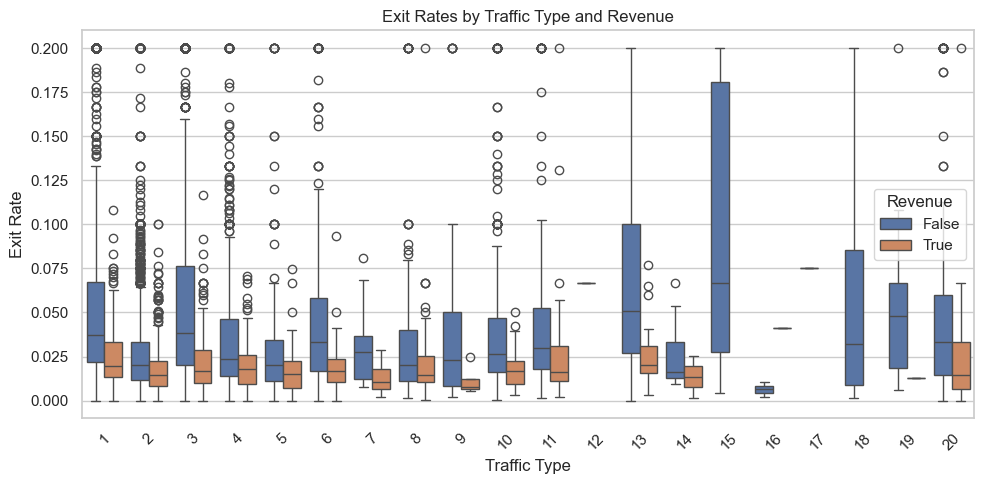

In [484]:
data4 = data[['ExitRates', 'TrafficType', 'VisitorType', 'Revenue']].dropna()

# Plot 1: ExitRates by TrafficType and VisitorType
plt.figure(figsize=(12, 6))
sns.boxplot(data=data4, x='TrafficType', y='ExitRates', hue='VisitorType')
plt.title('Exit Rates by Traffic Type and Visitor Type')
plt.xlabel('Traffic Type')
plt.ylabel('Exit Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 2: ExitRates by VisitorType and Revenue
plt.figure(figsize=(8, 5))
sns.boxplot(data=data4, x='VisitorType', y='ExitRates', hue='Revenue')
plt.title('Exit Rates by Visitor Type and Revenue')
plt.xlabel('Visitor Type')
plt.ylabel('Exit Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 3: ExitRates by TrafficType and Revenue
plt.figure(figsize=(10, 5))
sns.boxplot(data=data4, x='TrafficType', y='ExitRates', hue='Revenue')
plt.title('Exit Rates by Traffic Type and Revenue')
plt.xlabel('Traffic Type')
plt.ylabel('Exit Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

chatgpt explaination :
1. Exit Rates by Traffic Type & Visitor Type
This chart compares exit behavior for different visitor types (New, Returning, Other) across each traffic source.

Insight: Certain traffic types show higher exit rates for new visitors — these might indicate poor landing page relevance or first-time UX issues.

2. Exit Rates by Visitor Type and Revenue
Shows exit rate distribution for each visitor group, split by whether they made a purchase.

Insight:

Purchases are more frequent with lower exit rates, especially among returning visitors.

High exit rates usually correlate with non-purchase sessions.

3. Exit Rates by Traffic Type and Revenue
This examines how exit rates differ across traffic types between purchase vs non-purchase sessions.

Insight:

Some traffic sources (like Types 2, 8, 10) show lower exit rates when revenue is generated.

High-exit-rate sources may be poor in purchase intent or misaligned with product offering.


Is there a noticeable difference in Exit Rates based on whether a user visited the site on a weekend or not? [Variables: ExitRates, Weekend]

In [485]:
data['Weekend'] = data['Weekend'].astype(bool)
data5 = data[['ExitRates', 'Weekend']].dropna()

In [486]:
weekend_exit = data5[data5['Weekend'] == True]['ExitRates']
weekday_exit = data5[data5['Weekend'] == False]['ExitRates']

In [487]:
t_stat, p_val = ttest_ind(weekend_exit, weekday_exit, equal_var=False)

T-Test: ExitRates on Weekend vs Weekday
Mean Exit Rate - Weekend: 0.0375
Mean Exit Rate - Weekday: 0.0447
T-statistic: -7.4669
P-value: 9.5412e-14


C:\Users\User\AppData\Local\Temp\ipykernel_3780\3971172630.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data5, x='Weekend', y='ExitRates', palette='Set2')


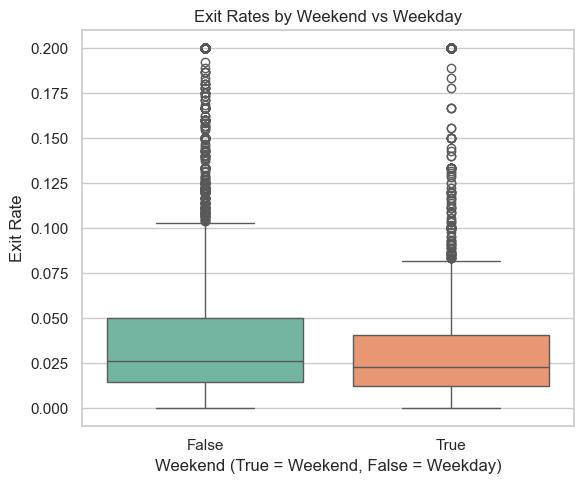

In [488]:
print("T-Test: ExitRates on Weekend vs Weekday")
print(f"Mean Exit Rate - Weekend: {weekend_exit.mean():.4f}")
print(f"Mean Exit Rate - Weekday: {weekday_exit.mean():.4f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4e}")

# Plot
plt.figure(figsize=(6, 5))
sns.boxplot(data=data5, x='Weekend', y='ExitRates', palette='Set2')
plt.title('Exit Rates by Weekend vs Weekday')
plt.xlabel('Weekend (True = Weekend, False = Weekday)')
plt.ylabel('Exit Rate')
plt.tight_layout()
plt.show()

chatgpt explaination :
Boxplot Summary:
X-axis: Weekend status (False = Weekday, True = Weekend)

Y-axis: Exit Rate — proportion of users who left the site from a given page.

🟩 Weekdays (False):
Median exit rate is slightly higher than weekends.

Wider spread in the interquartile range.

More high-value outliers (above 0.1).

🟧 Weekends (True):
Lower median and slightly tighter distribution.

Fewer high-value outliers than weekdays.

 T-Test Results:
Metric	Value
Mean (Weekday)	0.0447
Mean (Weekend)	0.0375
T-statistic	-7.4669
P-value	9.5412e-14


 Interpretation:
1. Difference in Means:
Exit rates are lower on weekends (3.75%) than on weekdays (4.47%), on average.

This suggests that users are slightly more engaged during weekends, leaving the site less frequently.

2. Statistical Significance:
The very small p-value (< 0.00001) means the difference in exit rates is statistically significant.

The t-statistic of -7.47 indicates a strong difference, with weekend values being consistently lower.

3. Practical Insight:
Although the difference (~0.007) is small, it is consistent enough across the sample to be considered meaningful.

This could imply higher user intent or better browsing behavior on weekends — possibly due to more leisure time or focused sessions.

✅ Recommendations:
Consider scheduling promotions, content releases, or A/B tests on weekends, when users are more engaged.

Analyze user behavior pathways on weekends vs weekdays to further understand what keeps them longer.

Is there a statistically significant difference in the average session duration between new visitors and returning visitors, and how does this difference impact the likelihood of generating revenue? [Variables: ProductRelated_Duration, VisitorType, Revenue]

In [489]:
data6 = data[data['VisitorType'].isin(['New_Visitor', 'Returning_Visitor'])]
data6 = data6[['ProductRelated_Duration', 'VisitorType', 'Revenue']].dropna()

In [490]:
new_visitors = data6[data6['VisitorType'] == 'New_Visitor']
returning_visitors = data6[data6['VisitorType'] == 'Returning_Visitor']

📊 T-Test: Session Duration (ProductRelated_Duration)
Mean Duration - New Visitors: 636.39
Mean Duration - Returning Visitors: 1289.42
T-statistic: -24.0666
P-value: 1.5018e-122


C:\Users\User\AppData\Local\Temp\ipykernel_3780\1001071779.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data6, x='VisitorType', y='ProductRelated_Duration', palette='Set3')


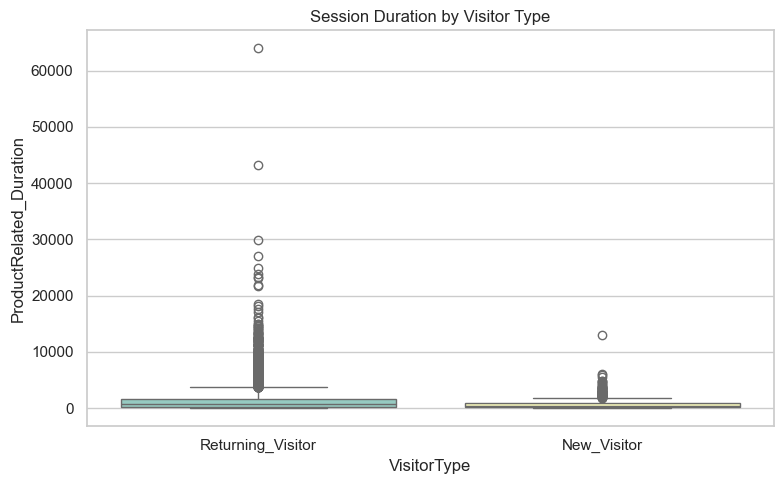

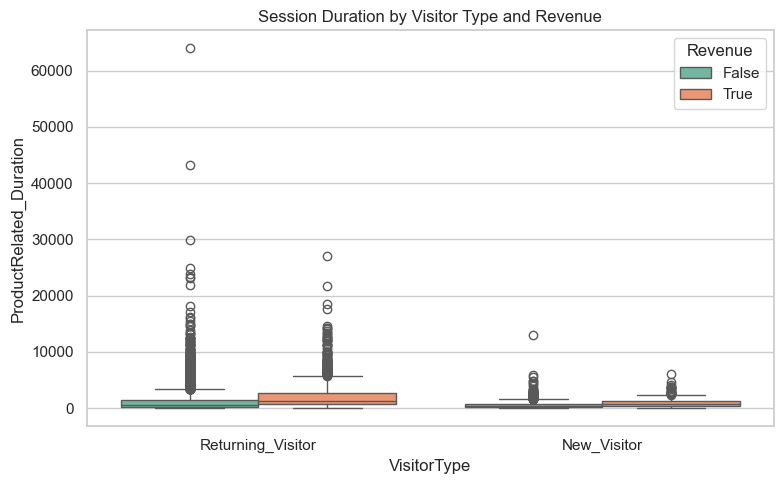

In [491]:
t_stat, p_val = ttest_ind(
    new_visitors['ProductRelated_Duration'],
    returning_visitors['ProductRelated_Duration'],
    equal_var=False
)

# Print results
print("📊 T-Test: Session Duration (ProductRelated_Duration)")
print(f"Mean Duration - New Visitors: {new_visitors['ProductRelated_Duration'].mean():.2f}")
print(f"Mean Duration - Returning Visitors: {returning_visitors['ProductRelated_Duration'].mean():.2f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4e}")

# Boxplot of durations by visitor type
plt.figure(figsize=(8, 5))
sns.boxplot(data=data6, x='VisitorType', y='ProductRelated_Duration', palette='Set3')
plt.title('Session Duration by Visitor Type')
plt.ylabel('ProductRelated_Duration')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=data6, x='VisitorType', y='ProductRelated_Duration', hue='Revenue', palette='Set2')
plt.title('Session Duration by Visitor Type and Revenue')
plt.ylabel('ProductRelated_Duration')
plt.tight_layout()
plt.show()

chatgpt explaination on t-test :
 T-Test Summary:
Metric	Value
Mean Duration – New Visitors	636.39 seconds
Mean Duration – Returning Visitors	1289.42 seconds
T-statistic	-24.0666
P-value	1.5018e-122


Interpretation:
1. Mean Difference:
Returning visitors spend over twice as long (≈ 1289 sec) on product-related pages compared to new visitors (≈ 636 sec).

This indicates much deeper engagement from returning users.

2. T-statistic and Direction:
A large negative t-statistic (-24.07) means the mean duration for new visitors is significantly lower than for returning ones.

The magnitude of this value shows a very strong difference between the two groups.

3. P-value:
The extremely small p-value (≈ 1.5e-122) confirms the difference is statistically significant — not due to random chance.

Behavioral Insight:
Returning visitors are likely more interested or already familiar with the site, so they spend more time exploring product details.

This also suggests return visits may lead to higher conversion potential, as time spent is often correlated with purchase intent.

✅ Recommendations:
Target new visitors with onboarding strategies (e.g., guided tours, recommendations) to boost their session duration.

Retarget returning users with personalized offers or reminders, as they show strong engagement already.

Consider tracking conversion rates by session duration to validate if longer engagement correlates with purchases.

Is there a statistically significant relationship between the average number of pages viewed (ProductRelated) and the session outcome (Revenue), considering the effects of visitor type (VisitorType) and time of day (SpecialDay)? [Variables: ProductRelated, Revenue, VisitorType, SpecialDay]

In [492]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [493]:
data7 = data[['ProductRelated', 'Revenue', 'VisitorType', 'SpecialDay']].dropna()
data7['Revenue'] = data7['Revenue'].astype(int)
data7['VisitorType'] = data7['VisitorType'].astype('category')

In [494]:
model = smf.ols('ProductRelated ~ Revenue + VisitorType + SpecialDay + Revenue:VisitorType + Revenue:SpecialDay', data=data7).fit()

In [495]:
anova_table = sm.stats.anova_lm(model, typ=2)
print("📊 Two-Way ANOVA Table:\n")
print(anova_table)

📊 Two-Way ANOVA Table:

                           sum_sq       df           F        PR(>F)
VisitorType          5.293611e+05      2.0  141.020327  2.792876e-61
Revenue              7.094936e+05      1.0  378.014274  5.858225e-83
Revenue:VisitorType  9.905429e+04      2.0   26.387791  3.667753e-12
SpecialDay           1.015314e+04      1.0    5.409535  2.004320e-02
Revenue:SpecialDay   1.701517e+04      1.0    9.065590  2.609923e-03
Residual             2.312712e+07  12322.0         NaN           NaN


chatgpt explaination :

Two-Way ANOVA Table Summary
Variable	F-value	p-value	Interpretation
VisitorType	141.02	2.79e-61 ✅	Strongly significant: Visitor type affects how many pages are viewed.
Revenue	378.01	5.86e-83 ✅	Strongly significant: Sessions that result in revenue tend to view more pages.
Revenue × VisitorType	26.39	3.67e-12 ✅	Interaction effect: The impact of purchase behavior depends on visitor type.
SpecialDay	5.41	0.020 ✅	Significant: Being near a special day slightly affects browsing depth.
Revenue × SpecialDay	9.07	0.0026 ✅	Interaction effect: Revenue-related browsing behavior differs on special days.


What This Means:
💵 Revenue Matters:

Sessions that end in purchases view significantly more product-related pages.

Indicates stronger engagement in successful sessions.

👤 Visitor Type Matters:

Different visitor types (e.g., Returning vs New) behave differently in browsing.

Returning visitors might view fewer or more specific pages.

⚡ VisitorType × Revenue Interaction:

The effect of purchasing on pages viewed varies by visitor type.

Example: Returning visitors might need fewer page views to convert, while new visitors might browse more before deciding.

📅 SpecialDay & Interaction:

Slight increase in browsing near special promotional days.

The impact of purchases is even greater on these days — more pages viewed when near promotions and a purchase occurs.

🔚 Conclusion:
✅ Yes, there is a statistically significant difference in the number of pages viewed based on:

Whether a session resulted in revenue

The type of visitor

And how close the session is to a special day

With important interaction effects — meaning the influence of one factor (like revenue) depends on another (like visitor type or special day).

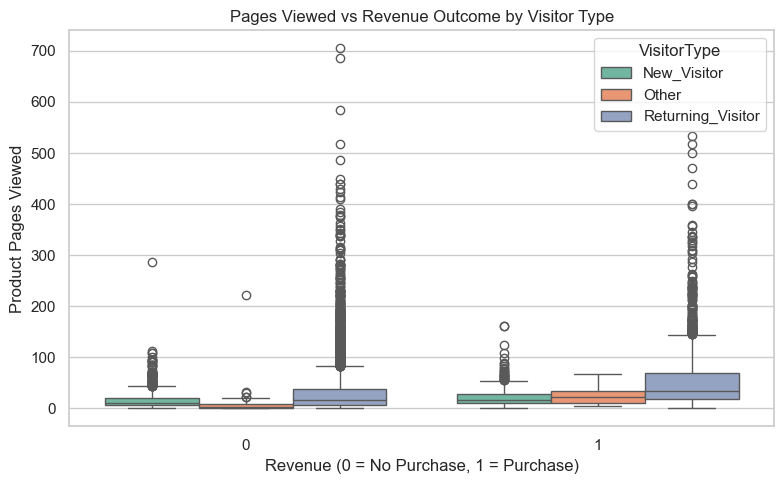

In [496]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=data7, x='Revenue', y='ProductRelated', hue='VisitorType', palette='Set2')
plt.title('Pages Viewed vs Revenue Outcome by Visitor Type')
plt.xlabel('Revenue (0 = No Purchase, 1 = Purchase)')
plt.ylabel('Product Pages Viewed')
plt.tight_layout()
plt.show()

Is there a statistically significant difference in the Page Value between new and returning visitors? [Variables: PageValues, VisitorType]

In [497]:
data8 = data[data['VisitorType'].isin(['New_Visitor', 'Returning_Visitor'])]
data8 = data8[['PageValues', 'VisitorType']].dropna()

In [498]:
new_visitors = data8[data8['VisitorType'] == 'New_Visitor']['PageValues']
returning_visitors = data8[data8['VisitorType'] == 'Returning_Visitor']['PageValues']

In [499]:
t_stat, p_val = ttest_ind(new_visitors, returning_visitors, equal_var=False)

📊 T-Test: PageValues between New and Returning Visitors
Mean Page Value - New Visitors: 10.7722
Mean Page Value - Returning Visitors: 5.0062
T-statistic: 7.9539
P-value: 3.1205e-15


C:\Users\User\AppData\Local\Temp\ipykernel_3780\1167190228.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data8, x='VisitorType', y='PageValues', palette='Set2')


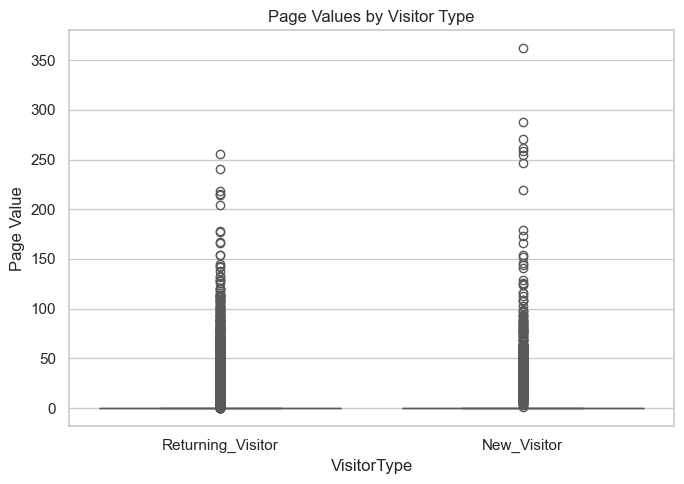

In [500]:
print("📊 T-Test: PageValues between New and Returning Visitors")
print(f"Mean Page Value - New Visitors: {new_visitors.mean():.4f}")
print(f"Mean Page Value - Returning Visitors: {returning_visitors.mean():.4f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4e}")

# Plot
plt.figure(figsize=(7, 5))
sns.boxplot(data=data8, x='VisitorType', y='PageValues', palette='Set2')
plt.title('Page Values by Visitor Type')
plt.ylabel('Page Value')
plt.tight_layout()
plt.show()

chaatgpt exlplaination t-test :
T-Test Results Summary
Metric	Value
Mean Page Value – New Visitors	10.7722
Mean Page Value – Returning Visitors	5.0062
T-statistic	7.9539
P-value	3.12 × 10⁻¹⁵ ✅

Statistical Significance

The p-value is extremely small (≪ 0.05), indicating a highly statistically significant difference in PageValues between the two groups.

We can confidently reject the null hypothesis:
There is a significant difference in page value between new and returning visitors.

Direction of Difference

New Visitors have a much higher average PageValue (10.77) than Returning Visitors (5.01).

This suggests that when New Visitors interact with the site, their visits are more likely to lead to higher potential revenue per session.

Practical Implication

New users may be more valuable in terms of revenue opportunity per session.

Could indicate:

They’re exploring more products

They’re interacting with higher-value pages

Or they’re more likely to respond to marketing/promotions

📌 Recommendations
Target New Visitors:
Focus marketing efforts on converting first-time visitors.

Re-engage Returning Visitors:
Consider personalization or incentives to increase their value per visit.

Can we predict the user purchase behaviour based on month and day of visit including whether it is special days or not ? [ Variables : SpecialDay , Month , Weekend , Revenue ]

In [501]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline  # use imblearn's pipeline


In [502]:
model9 = data[['SpecialDay', 'Month', 'Weekend', 'Revenue']].dropna()

In [503]:
model9['Revenue'] = model9['Revenue'].astype(int)

In [504]:
X = model9[['SpecialDay', 'Month', 'Weekend']]
y = model9['Revenue']

In [505]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [506]:
preprocessor = ColumnTransformer(
    transformers=[
        ('month', OneHotEncoder(drop='first'), ['Month']),
        ('bools', 'passthrough', ['Weekend']),
    ],
    remainder='passthrough'
)

In [507]:
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000))
])

In [508]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [509]:
print("📊 Logistic Regression with SMOTE - Classification Report:")
print(classification_report(y_test, y_pred))
print("✅ Accuracy Score:", accuracy_score(y_test, y_pred))

📊 Logistic Regression with SMOTE - Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.62      0.73      2084
           1       0.22      0.58      0.32       382

    accuracy                           0.62      2466
   macro avg       0.55      0.60      0.52      2466
weighted avg       0.79      0.62      0.67      2466

✅ Accuracy Score: 0.6155717761557178


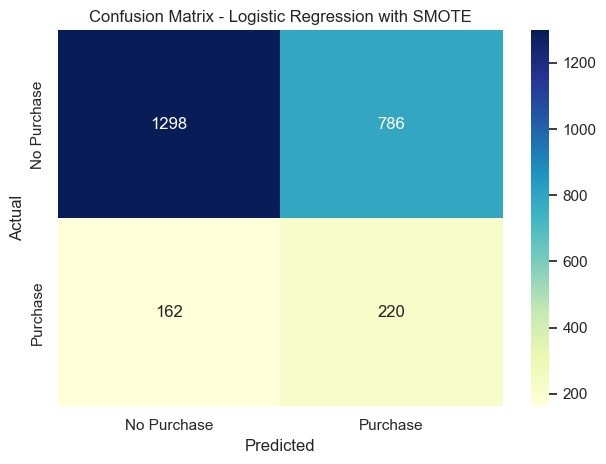

In [510]:
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=['No Purchase', 'Purchase'], 
            yticklabels=['No Purchase', 'Purchase'])
plt.title('Confusion Matrix - Logistic Regression with SMOTE')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

chatgpt explaination : 
Confusion Matrix Summary
Actual / Predicted	No Purchase (0)	Purchase (1)
No Purchase (0)	1298 (✅ correct)	786 (❌ wrong)
Purchase (1)	162 (❌ wrong)	220 (✅ correct)

The model correctly predicted:

1298 people who did not purchase.

220 people who did purchase.

But it also made many mistakes, especially:

786 non-purchasers were wrongly predicted as purchasers.

162 actual purchasers were predicted as non-purchasers.

Classification Report Summary
Metric	No Purchase (0)	Purchase (1)
Precision	0.89	0.22
Recall	0.62	0.58
F1-score	0.73	0.32

Overall Accuracy: 61.6%

Interpretation:
Recall for Purchase (1) is now 58%, which is a huge improvement from 0% before using SMOTE!
🔥 This means the model is now identifying over half of the actual purchases.

Precision for Purchase (1) is low (22%) — meaning many predicted purchases are actually wrong (false positives).

Trade-off: You're getting more Purchase predictions right, but at the cost of many wrong Purchase predictions.

Accuracy dropped from 85% to 61%, but this is expected and okay in imbalanced datasets — accuracy is no longer misleading, and now the model is actually learning about the minority class.

Does returning visitors who spend more time on educational content lead to an increase in users completing an order? [ Variables : Informational , Informational_Duration , VisitorType , Revenue ]

In [511]:
data10 = data[data['VisitorType'] == 'Returning_Visitor'].copy()
data10['Revenue'] = data10['Revenue'].astype(int)

In [512]:
purchased = data10[data10['Revenue'] == 1]
not_purchased = data10[data10['Revenue'] == 0]

In [513]:
t_info, p_info = ttest_ind(purchased['Informational'], not_purchased['Informational'], equal_var=False)
t_dur, p_dur = ttest_ind(purchased['Informational_Duration'], not_purchased['Informational_Duration'], equal_var=False)


In [514]:
print("📊 Mean Informational Pages:")
print(f"Purchase: {purchased['Informational'].mean():.2f} | No Purchase: {not_purchased['Informational'].mean():.2f}")
print(f"T-statistic: {t_info:.4f} | P-value: {p_info:.4e}")

print("\n📊 Mean Informational Duration:")
print(f"Purchase: {purchased['Informational_Duration'].mean():.2f} | No Purchase: {not_purchased['Informational_Duration'].mean():.2f}")
print(f"T-statistic: {t_dur:.4f} | P-value: {p_dur:.4e}")


📊 Mean Informational Pages:
Purchase: 0.94 | No Purchase: 0.47
T-statistic: 10.4455 | P-value: 8.1028e-25

📊 Mean Informational Duration:
Purchase: 68.82 | No Purchase: 31.97
T-statistic: 7.1743 | P-value: 1.0715e-12


C:\Users\User\AppData\Local\Temp\ipykernel_3780\526041398.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data10, x='Revenue', y='Informational', palette='pastel')
C:\Users\User\AppData\Local\Temp\ipykernel_3780\526041398.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data10, x='Revenue', y='Informational_Duration', palette='pastel')


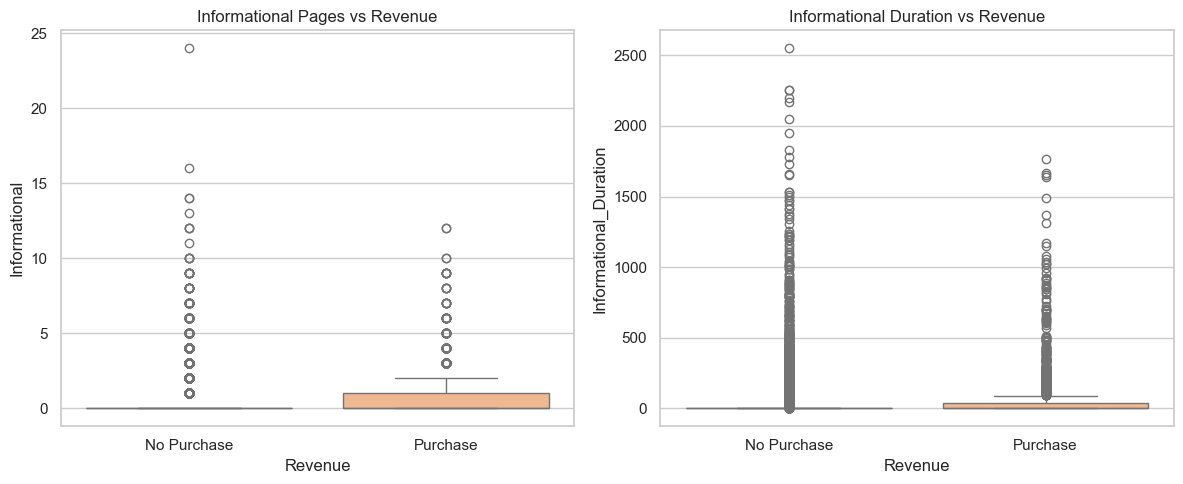

In [515]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=data10, x='Revenue', y='Informational', palette='pastel')
plt.title('Informational Pages vs Revenue')
plt.xticks([0, 1], ['No Purchase', 'Purchase'])

plt.subplot(1, 2, 2)
sns.boxplot(data=data10, x='Revenue', y='Informational_Duration', palette='pastel')
plt.title('Informational Duration vs Revenue')
plt.xticks([0, 1], ['No Purchase', 'Purchase'])

plt.tight_layout()
plt.show()

chatgpt explaination :

1. Mean Informational Pages
People who made a purchase visited 0.94 informational pages on average.

People who didn’t purchase visited only 0.47 pages on average.

T-statistic = 10.4455 → this is a big number, showing a large difference.

P-value = 8.10 × 10⁻²⁵ → extremely small (almost 0), meaning this difference is very statistically significant.

✅ Conclusion:

Visitors who purchased tend to visit more informational pages than those who didn’t. This is not by chance — it's a real, meaningful difference.

📊 2. Mean Informational Duration
Purchasers spent 68.82 seconds (on average) on informational pages.

Non-purchasers spent only 31.97 seconds.

T-statistic = 7.1743, still a large difference.

P-value = 1.07 × 10⁻¹² → also very small, so again, highly significant.

✅ Conclusion:

Shoppers who eventually made a purchase also spent more time on informational pages — and this difference is real, not random.

🧠 Final Interpretation:
Both the number of informational pages and the time spent on them are strong indicators of purchase behavior.

This suggests:

Users who take time to read or research products are more likely to buy.

These two features are valuable predictors for your model (maybe even top features).

To what extent do Product-Related Duration, Informational Duration, Exit Rate, and Page Value jointly influence the likelihood of a session ending in a purchase? [Variables: ProductRelated_Duration, Informational_Duration, ExitRates, PageValues, Revenue]

In [516]:
import numpy as np

In [517]:
features = ['ProductRelated_Duration', 'Informational_Duration', 'ExitRates', 'PageValues']
X = data[features].dropna()
y = data.loc[X.index, 'Revenue'] 

In [518]:
X_train10, X_test, y_train10, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [519]:
model10 = LogisticRegression(max_iter=1000)
model10.fit(X_train10, y_train10)
y_pred = model10.predict(X_test)

In [520]:
print("📊 Classification Report:")
print(classification_report(y_test, y_pred))
print("✅ Accuracy Score:", accuracy_score(y_test, y_pred))

📊 Classification Report:
              precision    recall  f1-score   support

       False       0.89      0.98      0.93      2091
        True       0.75      0.33      0.46       375

    accuracy                           0.88      2466
   macro avg       0.82      0.65      0.70      2466
weighted avg       0.87      0.88      0.86      2466

✅ Accuracy Score: 0.8815896188158961


In [521]:
coeffs = model10.coef_[0]
odds_ratios = np.exp(coeffs)

summary = pd.DataFrame({
    'Feature': features,
    'Coefficient': coeffs,
    'Odds Ratio': odds_ratios
}).sort_values(by='Odds Ratio', ascending=False)

In [522]:
print("\n📈 Feature Impact Summary (Log-Odds and Odds Ratios):")
print(summary)


📈 Feature Impact Summary (Log-Odds and Odds Ratios):
                   Feature  Coefficient  Odds Ratio
3               PageValues     0.082256    1.085734
0  ProductRelated_Duration     0.000150    1.000150
1   Informational_Duration     0.000062    1.000062
2                ExitRates    -6.289785    0.001855


C:\Users\User\AppData\Local\Temp\ipykernel_3780\3446449428.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Odds Ratio', y='Feature', data=summary, palette='viridis')


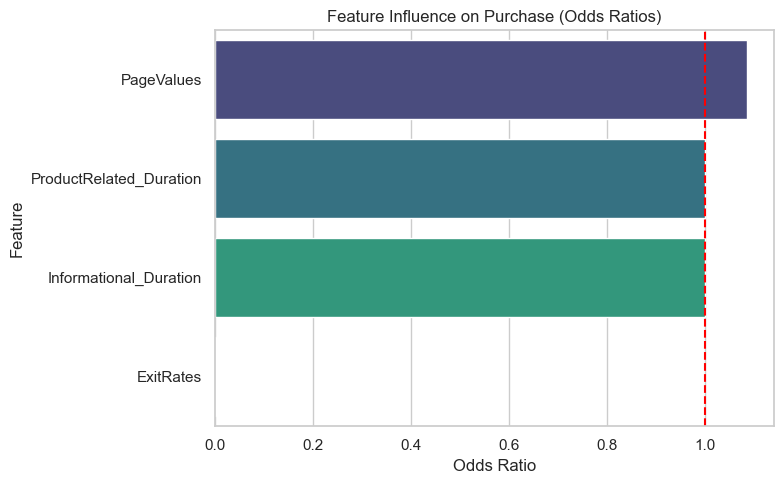

In [523]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Odds Ratio', y='Feature', data=summary, palette='viridis')
plt.axvline(1, color='red', linestyle='--')
plt.title("Feature Influence on Purchase (Odds Ratios)")
plt.tight_layout()
plt.show()

chatgpt explaination :
Feature Impact Summary
Feature	Coefficient (Log-Odds)	Odds Ratio	Interpretation
PageValues	0.0823	1.086	✅ Small positive effect — every 1-unit increase in Page Value increases the odds of purchase by ~8.6%.
ProductRelated_Duration	0.00015	1.00015	➕ Very minimal positive effect — each second spent on product pages slightly increases purchase likelihood.
Informational_Duration	0.000062	1.00006	➕ Negligible positive effect — educational content time adds marginal influence.
ExitRates	-6.2898	0.00186	❌ Strong negative effect — higher exit rate drastically reduces the chance of purchase (~99.8% lower odds).

Key Takeaways
✅ Most Influential Feature: ExitRates
A high exit rate is a very strong indicator of session abandonment.

It reduces the odds of purchasing by ~99.8% — users who exit quickly almost never convert.

➕ Moderate Influence: PageValues
Sessions with higher PageValues (pages that historically lead to revenue) are more likely to convert.

A 1-point increase in Page Value raises purchase odds by ~8.6%.

⚖️ Minor Impact: Durations
Time spent on product-related or informational content has a tiny positive impact, but not strongly predictive on their own.

May become more meaningful when combined with other behavioral signals.

Interpretation Summary
This model shows that:

ExitRates is a strong negative predictor — sessions with high exit rates almost never result in revenue.

PageValues is the most actionable positive predictor — encourage traffic through high-value pages.

Time-based metrics like duration have some effect, but they’re weak predictors in isolation

What strategies can be implemented to optimize traffic type and session length (ProductRelated_Duration) in order to increase the likelihood of a session resulting in revenue? [Variables: ProductRelated_Duration, TrafficType, Revenue]

In [524]:
data['DurationBin'] = pd.cut(data['ProductRelated_Duration'],
                           bins=[-1, 0, 100, 300, 600, 1200, np.inf],
                           labels=['0s', '0-100s', '100-300s', '300-600s', '600-1200s', '1200s+'])


In [525]:
data12 = data.groupby(['TrafficType', 'DurationBin'])['Revenue'].mean().reset_index()
data12['Revenue'] = data12['Revenue'] * 100  # Convert to percentage

C:\Users\User\AppData\Local\Temp\ipykernel_3780\2928177528.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data12 = data.groupby(['TrafficType', 'DurationBin'])['Revenue'].mean().reset_index()


C:\Users\User\AppData\Local\Temp\ipykernel_3780\1442493260.py:7: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\User\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


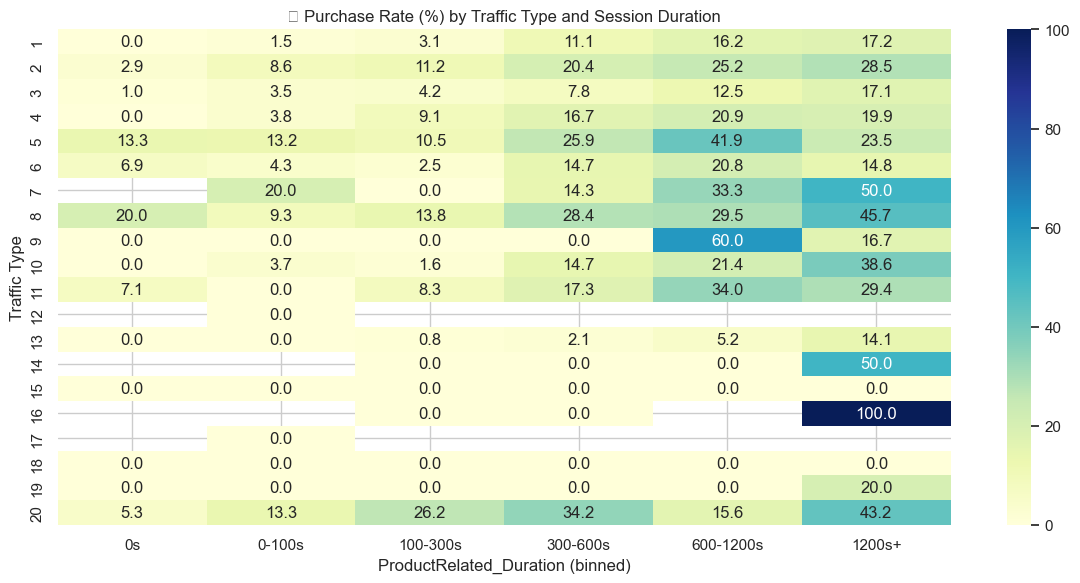

In [526]:
plt.figure(figsize=(12, 6))
sns.heatmap(data12.pivot(index='TrafficType', columns='DurationBin', values='Revenue'),
            annot=True, fmt=".1f", cmap='YlGnBu')
plt.title('🔥 Purchase Rate (%) by Traffic Type and Session Duration')
plt.ylabel("Traffic Type")
plt.xlabel("ProductRelated_Duration (binned)")
plt.tight_layout()
plt.show()

In [527]:
model12 = data[['TrafficType', 'ProductRelated_Duration', 'Revenue']].copy()
model12 = pd.get_dummies(model12, columns=['TrafficType'], drop_first=True)

In [528]:
X = model12.drop(columns='Revenue')
y = model12['Revenue']

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

LogisticRegression(max_iter=1000)

In [529]:
coeffs = pd.Series(model.coef_[0], index=X.columns)
coeffs = coeffs.sort_values(key=abs, ascending=False)

In [530]:
print("\n📈 Feature Coefficients (absolute strength):")
print(coeffs)


📈 Feature Coefficients (absolute strength):
TrafficType_7              1.266888
TrafficType_8              1.195675
TrafficType_20             1.092488
TrafficType_5              0.930981
TrafficType_2              0.803116
TrafficType_15            -0.753507
TrafficType_11             0.738360
TrafficType_10             0.723973
TrafficType_13            -0.698893
TrafficType_4              0.477747
TrafficType_19            -0.261297
TrafficType_18            -0.240217
TrafficType_16             0.171715
TrafficType_6              0.159167
TrafficType_3             -0.157182
TrafficType_14            -0.070696
TrafficType_9             -0.025369
TrafficType_17            -0.024166
TrafficType_12            -0.024000
ProductRelated_Duration    0.000176
dtype: float64


chatgpt explaination :
 Top Positive Influences on Revenue
Feature	Coefficient	Interpretation
TrafficType_7	+1.267	🚀 Very strong positive effect — sessions from Traffic Type 7 are much more likely to convert.
TrafficType_8	+1.196	🔥 Strong boost — Traffic Type 8 sessions are also highly likely to result in purchases.
TrafficType_20	+1.092	✅ Substantial positive influence — this traffic type shows high revenue potential.
TrafficType_5/2/11/10	+0.7 to +0.9	🟢 Moderate positive influence — users from these traffic types convert better than baseline.

🔻 Negative Influences on Revenue
Feature	Coefficient	Interpretation
TrafficType_15	−0.754	❌ Strongly associated with non-purchase sessions.
TrafficType_13	−0.699	🔻 Also reduces likelihood of purchase.
TrafficType_3/14/9...	−0.1 to −0.25	🟡 Minor to moderate negative influence. These types don’t perform well.

🕒 ProductRelated_Duration
Feature	Coefficient	Interpretation
ProductRelated_Duration	+0.000176	⏱️ Small but positive effect — longer time spent on product pages slightly increases the chance of purchase.
(Every second adds a tiny boost.)

✅ Actionable Takeaways
Prioritize Traffic Types 7, 8, and 20 in marketing campaigns — they have the highest conversion potential.

De-emphasize or investigate Traffic Types 13 and 15, which may be attracting low-converting users.

Encourage longer engagement with product pages, even small increases in duration can help.

Consider segmenting by traffic type for personalized user experiences.